## 1. Introduction & Data Ingestion
To begin our analysis of the Titanic survival dataset, we first establish our environment by mounting our file system and importing the necessary data manipulation and visualization libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`). Our primary goal is to predict passenger survival based on available features, balancing model complexity with the risk of overfitting on a relatively small dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')
folder_path = '/content/drive/MyDrive/BananaMining/'

Mounted at /content/drive/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

try:
    train_df = pd.read_csv(folder_path + 'train.csv')
    test_df = pd.read_csv(folder_path + 'test.csv')
    print("✅ Datasets loaded successfully!")
except FileNotFoundError:
    print("❌ Error: File not found. Please double-check the folder path and filenames.")

✅ Datasets loaded successfully!


## 2. Initial Data Inspection
Before engineering features or training models, we must understand the shape and health of our data. We inspect the first few rows, data types, and descriptive statistics. Critically, we check for missing values to inform our imputation strategy.

* **Observation**: The `Age`, `Cabin`, and `Embarked` columns contain missing values that must be addressed before modeling.

In [3]:
print("--- First 5 rows of the training dataset ---")
display(train_df.head())

print("\n--- Dataset Information (Columns and Data Types) ---")
train_df.info()

print("\n--- Descriptive Statistics (Numerical Variables) ---")
display(train_df.describe())

print("\n--- Missing Values Count ---")
display(train_df.isnull().sum())

--- First 5 rows of the training dataset ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Dataset Information (Columns and Data Types) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Descriptive Statistics (Numerical Variables) ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Missing Values Count ---


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 3. Exploratory Data Analysis (EDA)
We use visual EDA to identify strong correlations between single features and the target variable (`Survived`).
* **Gender**: Historically, the "women and children first" protocol was enforced. We expect gender to be a massive indicator of survival.
* **Passenger Class (`Pclass`)**: Socio-economic status likely played a role in survival rates, which we visualize by looking at the age distribution across different classes.

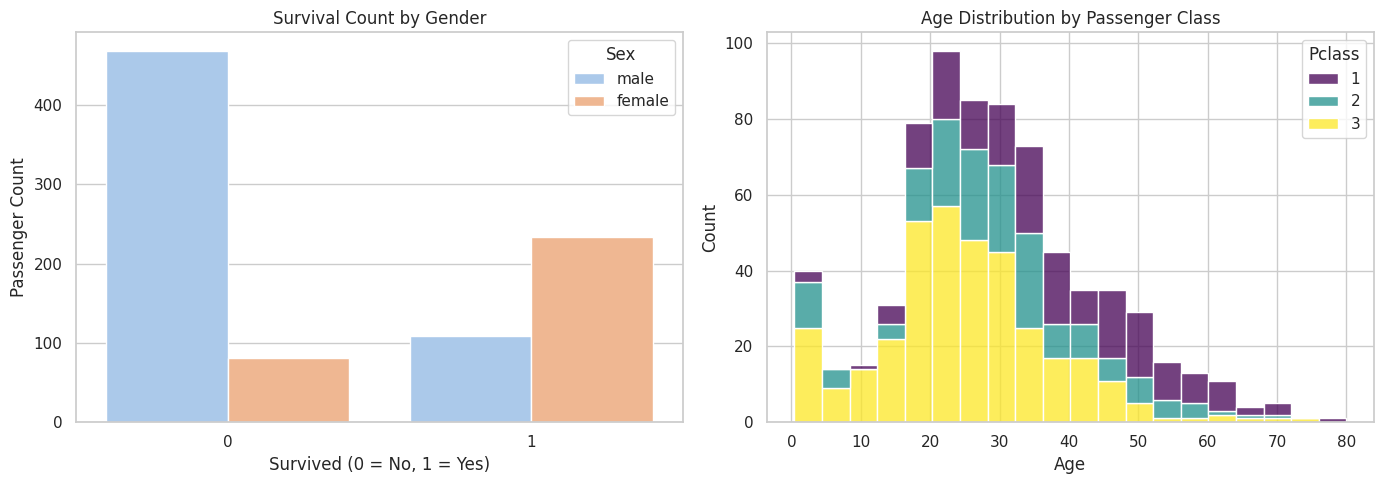

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train_df, x='Survived', hue='Sex', palette='pastel', ax=axes[0])
axes[0].set_title('Survival Count by Gender')
axes[0].set_xlabel('Survived (0 = No, 1 = Yes)')
axes[0].set_ylabel('Passenger Count')

sns.histplot(data=train_df, x='Age', hue='Pclass', multiple='stack', palette='viridis', ax=axes[1])
axes[1].set_title('Age Distribution by Passenger Class')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Exploring Age Distribution
Exploring the `Age` variable reveals the demographic breakdown of survivors. Using a filled density histogram helps us see the proportion of survival across specific age groups (like young children), confirming if they had a disproportionately higher survival rate compared to adults or the elderly.

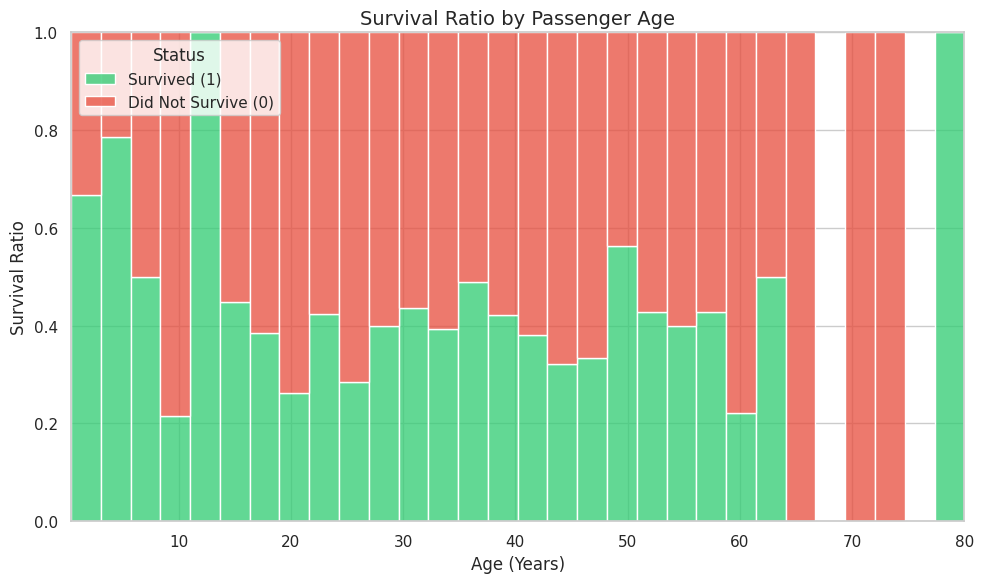

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=train_df,
    x='Age',
    hue='Survived',
    multiple='fill',
    palette={0: '#e74c3c', 1: '#2ecc71'},
    kde=False,
    bins=30
)

plt.title('Survival Ratio by Passenger Age', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Survival Ratio', fontsize=12)

plt.legend(title='Status', labels=['Survived (1)', 'Did Not Survive (0)'])

plt.tight_layout()
plt.show()

### Embarkation Port Analysis
Finally, we analyze the port of embarkation. While the port itself might not directly cause survival, it could correlate strongly with Passenger Class or Gender demographics, making it a potentially useful proxy variable.

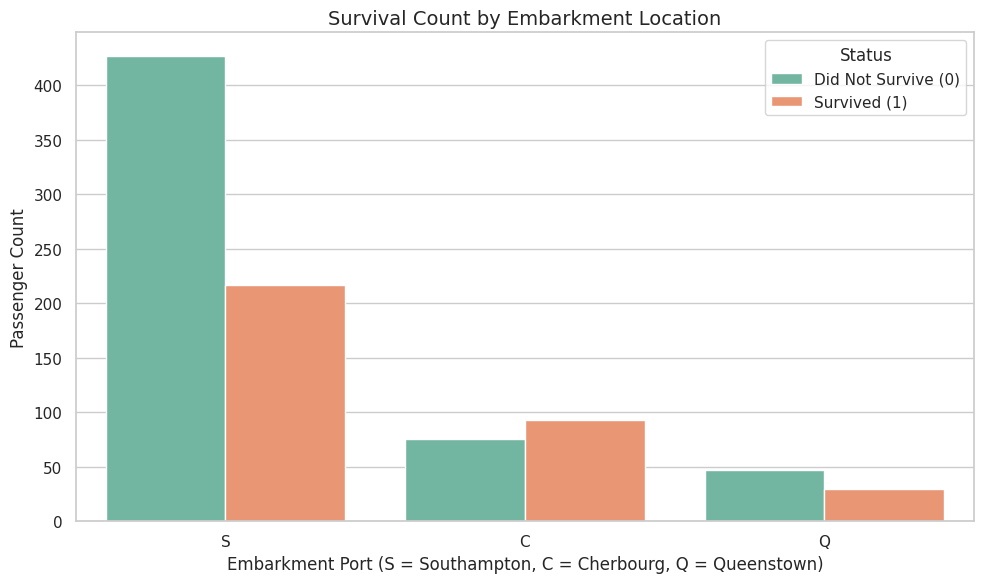

In [6]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=train_df,
    x='Embarked',
    hue='Survived',
    palette='Set2',
    hue_order=[0, 1]
)

plt.title('Survival Count by Embarkment Location', fontsize=14)
plt.xlabel('Embarkment Port (S = Southampton, C = Cherbourg, Q = Queenstown)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

plt.legend(title='Status', labels=['Did Not Survive (0)', 'Survived (1)'])

plt.tight_layout()
plt.show()

## 4. Basic Data Cleaning & Preprocessing
Based on our EDA, we apply our first round of data cleaning:
1. **Drop High-Cardinality/Text Columns**: `PassengerId`, `Name`, and `Ticket` are dropped. While they contain hidden signals (like titles in names), they require complex NLP extraction and add noise to simple models.
2. **Encode Categoricals**: We map `Sex` to a binary numeric format and apply one-hot encoding to `Embarked`.
3. **Impute Missing Values**: We fill missing `Age` values with the dataset's mean to retain these rows without skewing the distribution significantly.

In [7]:
train_df_cleaned = train_df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
train_df_cleaned['Sex'] = train_df_cleaned['Sex'].map({'male': 0, 'female': 1})
train_df_cleaned = pd.get_dummies(train_df_cleaned, columns=['Embarked'], dtype=int)
train_df_cleaned['Age'] = train_df_cleaned['Age'].fillna(train_df_cleaned['Age'].mean())

print("Cleaned DataFrame head:")
display(train_df_cleaned.head())

Cleaned DataFrame head:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,NaN,0,0,1
1,1,1,1,38.0,1,0,71.2833,C85,1,0,0
2,1,3,1,26.0,0,0,7.9250,NaN,0,0,1
3,1,1,1,35.0,1,0,53.1000,C123,0,0,1
4,0,3,0,35.0,0,0,8.0500,NaN,0,0,1


## 5. Advanced Feature Engineering: The Cabin Column
The `Cabin` feature contains a massive amount of missing data, but the data that is there is highly structured. Instead of dropping it outright, we extract latent information:
* **CabinCount**: Passengers booking multiple cabins might represent wealthier families.
* **CabinNumber**: The numerical location of the cabin.
* **Deck**: The letter prefix of the cabin (A, B, C, etc.) indicates the deck level, which dictates proximity to lifeboats. We one-hot encode these decks.

In [8]:
ALL_DECKS = ["A", "B", "C", "D", "E", "F", "G", "T", "U"]

def add_cabin_features(df):
    df = df.copy()

    cabin_text = df["Cabin"].fillna("U").astype(str).str.strip()

    df["CabinCount"] = np.where(
        cabin_text.eq("U"),
        0,
        cabin_text.str.split().str.len()
    ).astype(int)

    cabin_tokens = cabin_text.str.split()

    first_cabin = cabin_tokens.str[0]

    df["CabinNumber"] = pd.to_numeric(
        first_cabin.str.extract(r"(\d+)", expand=False),
        errors="coerce"
    ).fillna(-1)

    deck_lists = cabin_text.str.findall(r"[A-Za-z]").apply(
        lambda decks: sorted(set(deck.upper() for deck in decks)) if decks else ["U"]
    )

    deck_one_hot = pd.DataFrame(
        {
            f"Deck_{deck}": deck_lists.apply(lambda decks: int(deck in decks))
            for deck in ALL_DECKS
        },
        index=df.index
    )

    df = pd.concat([df, deck_one_hot], axis=1)

    return df

In [9]:
train_df_cleaned = add_cabin_features(train_df_cleaned)

In [10]:
train_df_cleaned = train_df_cleaned.drop(columns=["Cabin"])

In [11]:
display(train_df_cleaned.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,...,CabinNumber,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
0,0,3,0,22.0,1,0,7.2500,0,0,1,...,-1.0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0,...,85.0,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1,...,-1.0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1,...,123.0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,0,0,1,...,-1.0,0,0,0,0,0,0,0,0,1


## 6. Evaluating Engineered Features
To validate our feature engineering, we check the correlation between our new `CabinCount` feature and survival. The data confirms our hypothesis: passengers associated with multiple cabins had a significantly higher survival rate (58%) compared to those with a single cabin or missing cabin data (38%).

Number of people with multiple cabins: 24
Survival rate for people with multiple cabins: 0.58
Survival rate for people with a single or no cabin: 0.38


/tmp/ipykernel_837/3081789597.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_df_cleaned['CabinCount'] > 1, y=train_df_cleaned['Survived'], palette='viridis')


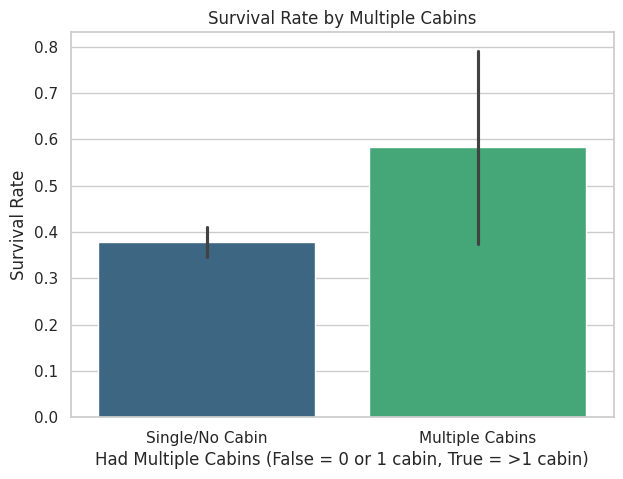

In [12]:
num_multiple_cabins = train_df_cleaned[train_df_cleaned['CabinCount'] > 1].shape[0]
print(f"Number of people with multiple cabins: {num_multiple_cabins}")

survival_rate_multiple_cabins = train_df_cleaned[train_df_cleaned['CabinCount'] > 1]['Survived'].mean()
survival_rate_single_or_no_cabin = train_df_cleaned[train_df_cleaned['CabinCount'] <= 1]['Survived'].mean()

print(f"Survival rate for people with multiple cabins: {survival_rate_multiple_cabins:.2f}")
print(f"Survival rate for people with a single or no cabin: {survival_rate_single_or_no_cabin:.2f}")

plt.figure(figsize=(7, 5))
sns.barplot(x=train_df_cleaned['CabinCount'] > 1, y=train_df_cleaned['Survived'], palette='viridis')
plt.title('Survival Rate by Multiple Cabins')
plt.xlabel('Had Multiple Cabins (False = 0 or 1 cabin, True = >1 cabin)')
plt.ylabel('Survival Rate')
plt.xticks(ticks=[0, 1], labels=['Single/No Cabin', 'Multiple Cabins'])
plt.show()

## 7. Wealth Indicators and Survival Correlations
Here we analyze how wealth metrics like `Pclass` (socio-economic status), `Fare` (price paid for the ticket), and `CabinCount` (number of booked cabins) relate to the passenger's likelihood of survival. We can clearly see that socioeconomic standing heavily influenced rescue priority.

=== Correlation of Wealth Indicators with Survival ===


,Survived
Pclass,-0.338481
Fare,0.257307
CabinCount,0.277053
Survived,1.000000


/tmp/ipykernel_837/722712797.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Pclass', y='Survived', palette='Blues_d', ax=axes[0])
/tmp/ipykernel_837/722712797.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df.assign(Survived_str=train_df['Survived'].astype(str)), x='Survived_str', y='Fare', palette={'0': '#e74c3c', '1': '#2ecc71'}, ax=axes[1])


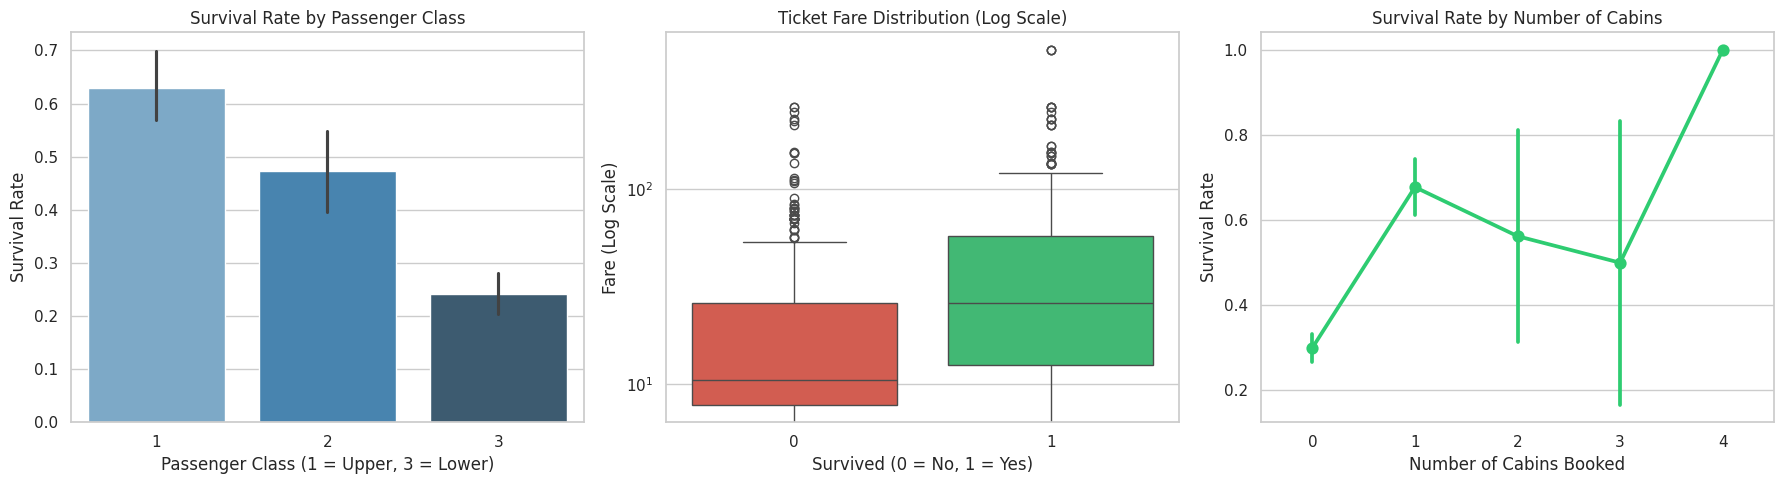

In [13]:
wealth_cols = ['Pclass', 'Fare', 'CabinCount', 'Survived']
correlation_matrix = train_df_cleaned[wealth_cols].corr()

print("=== Correlation of Wealth Indicators with Survival ===")
display(correlation_matrix[['Survived']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=train_df, x='Pclass', y='Survived', palette='Blues_d', ax=axes[0])
axes[0].set_title('Survival Rate by Passenger Class')
axes[0].set_xlabel('Passenger Class (1 = Upper, 3 = Lower)')
axes[0].set_ylabel('Survival Rate')

sns.boxplot(data=train_df.assign(Survived_str=train_df['Survived'].astype(str)), x='Survived_str', y='Fare', palette={'0': '#e74c3c', '1': '#2ecc71'}, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Ticket Fare Distribution (Log Scale)')
axes[1].set_xlabel('Survived (0 = No, 1 = Yes)')
axes[1].set_ylabel('Fare (Log Scale)')

sns.pointplot(data=train_df_cleaned, x='CabinCount', y='Survived', color='#2ecc71', ax=axes[2])
axes[2].set_title('Survival Rate by Number of Cabins')
axes[2].set_xlabel('Number of Cabins Booked')
axes[2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

### Gender Proportion Check
We also visualize the proportion of survivors within each gender to examine the striking demographic differences in survival likelihood.

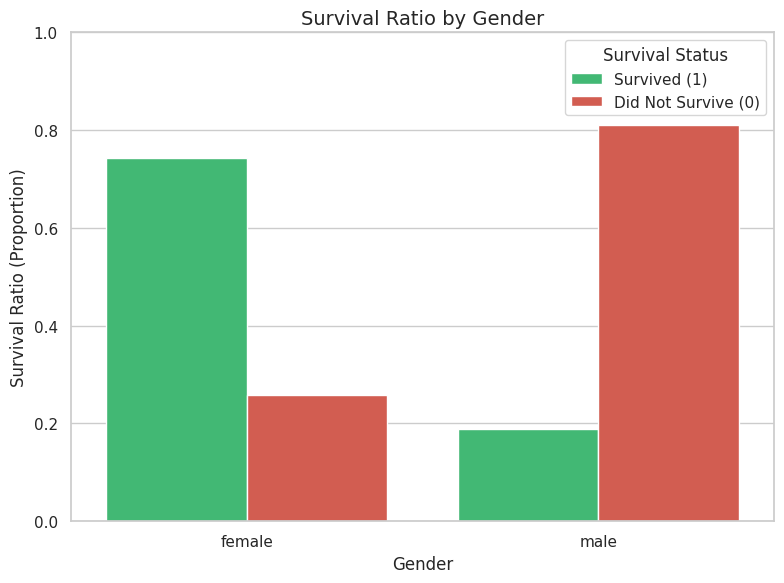

In [14]:
gender_survival = train_df.groupby('Sex')['Survived'].value_counts(normalize=True).rename('Proportion').reset_index()
gender_survival['Survived'] = gender_survival['Survived'].map({0: 'Did Not Survive (0)', 1: 'Survived (1)'})

plt.figure(figsize=(8, 6))

sns.barplot(
    data=gender_survival,
    x='Sex',
    y='Proportion',
    hue='Survived',
    palette={'Did Not Survive (0)': '#e74c3c', 'Survived (1)': '#2ecc71'}
)

plt.title('Survival Ratio by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Ratio (Proportion)', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Survival Status')

plt.tight_layout()
plt.show()

## 8. Splitting the Data
Before generating final predictions, we split our data into training and validation sets. This allows us to evaluate and compare different modeling techniques locally, avoiding reliance solely on Kaggle submissions for validation.

In [15]:
from sklearn.model_selection import train_test_split

X = train_df_cleaned.drop('Survived', axis=1)
y = train_df_cleaned['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 9. Baseline Model Training
We establish a baseline using three classic tree-based classifiers: Decision Trees, Random Forests, and Gradient Boosting.

**Note on Architecture choice:** We did not consider deep learning techniques given the small size of the dataset and the relative simplicity of the classification task. This is a classic tabular scenario where models with smaller variance and higher bias perform exceptionally well and avoid catastrophic overfitting.

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_val)
rf_preds = rf_model.predict(X_val)
gb_preds = gb_model.predict(X_val)

print(f"Decision Tree Accuracy: {accuracy_score(y_val, dt_preds):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_val, rf_preds):.4f}")
print(f"Gradient Boosting Accuracy: {accuracy_score(y_val, gb_preds):.4f}")

Decision Tree Accuracy: 0.7486
Random Forest Accuracy: 0.7877
Gradient Boosting Accuracy: 0.7821


## 10. Robust Evaluation via Cross-Validation
A single train-validation split can be heavily influenced by random chance. To acquire a more robust estimate of model generalization, we apply 5-fold cross-validation across the entire training set.

In [17]:
from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
gb_scores = cross_val_score(gb_model, X, y, cv=5, scoring='accuracy')

print(f"Decision Tree CV Accuracy: {np.mean(dt_scores):.4f} (+/- {np.std(dt_scores):.4f})")
print(f"Random Forest CV Accuracy: {np.mean(rf_scores):.4f} (+/- {np.std(rf_scores):.4f})")
print(f"Gradient Boosting CV Accuracy: {np.mean(gb_scores):.4f} (+/- {np.std(gb_scores):.4f})")

Decision Tree CV Accuracy: 0.7700 (+/- 0.0229)
Random Forest CV Accuracy: 0.8126 (+/- 0.0264)
Gradient Boosting CV Accuracy: 0.8227 (+/- 0.0374)


## 11. Hyperparameter Tuning (GridSearch)
To squeeze out peak performance, we employ `GridSearchCV` to test combinations of hyperparameters exhaustively. For Random Forests, we control depth and splits to prevent overfitting. For Gradient Boosting, we tune the learning rate, max depth, and subsampling strategy.

In [18]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("=== Random Forest Hyperparameter Tuning ===")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best CV Score: {grid_rf.best_score_:.4f}")

best_rf_model = grid_rf.best_estimator_
rf_val_acc = accuracy_score(y_val, best_rf_model.predict(X_val))
print(f"Validation Accuracy (Tuned): {rf_val_acc:.4f}\n")

gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print("=== Gradient Boosting Hyperparameter Tuning ===")
print(f"Best Parameters: {grid_gb.best_params_}")
print(f"Best CV Score: {grid_gb.best_score_:.4f}")

best_gb_model = grid_gb.best_estimator_
gb_val_acc = accuracy_score(y_val, best_gb_model.predict(X_val))
print(f"Validation Accuracy (Tuned): {gb_val_acc:.4f}")

=== Random Forest Hyperparameter Tuning ===
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score: 0.8329
Validation Accuracy (Tuned): 0.7765

=== Gradient Boosting Hyperparameter Tuning ===
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Best CV Score: 0.8246
Validation Accuracy (Tuned): 0.7933


## 12. Feature Importance Analysis
After tuning, we extract the `feature_importances_` from our optimal Gradient Boosting model. Visualizing this tells us exactly what drives the predictions. Often, complex engineered features add noise instead of signal and inadvertently increase the dimensionality risk.

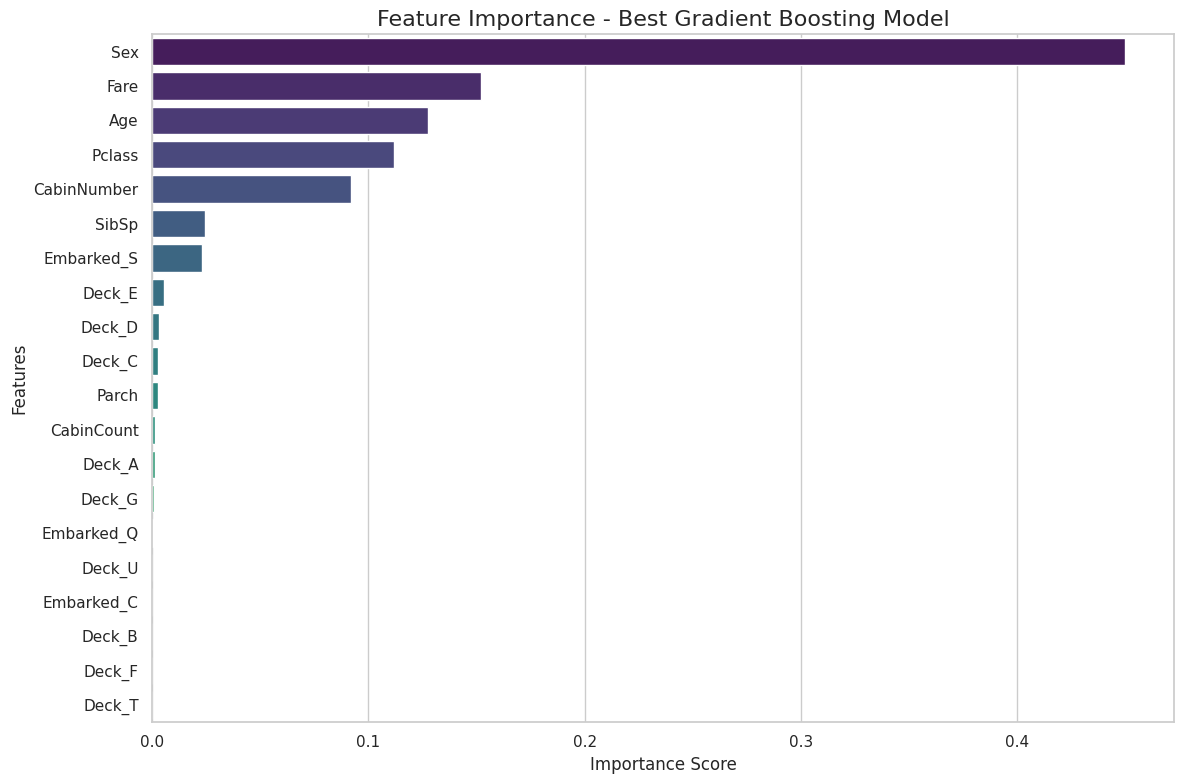

In [19]:
importances = best_gb_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Feature Importance - Best Gradient Boosting Model', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Dimensionality Reduction: Attempt 1
Guided by the feature importance chart, we remove the noisy `Deck` and `Embarked` features, alongside `CabinCount` and `CabinNumber`. Trimming the fat creates a leaner, more robust pipeline.

In [47]:
columns_to_drop = [col for col in X.columns if col.startswith('Deck_') or col.startswith('Embarked_')] + ['CabinCount', 'CabinNumber', 'Parch']

X_reduced = X.drop(columns=columns_to_drop)

print("Features remaining in the reduced dataset:")
print(list(X_reduced.columns))

X_train_red, X_val_red, y_train_red, y_val_red = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

Features remaining in the reduced dataset:
['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']


## 14. Validating the Reduced Feature Set (Attempt 1)
We retrain our models on this simplified feature set to ensure that performance holds steady or improves.

In [48]:
dt_model_red = DecisionTreeClassifier(random_state=42)
rf_model_red = RandomForestClassifier(n_estimators=100, random_state=42)
gb_model_red = GradientBoostingClassifier(n_estimators=100, random_state=42)

dt_model_red.fit(X_train_red, y_train_red)
rf_model_red.fit(X_train_red, y_train_red)
gb_model_red.fit(X_train_red, y_train_red)

print(f"Reduced Decision Tree Accuracy: {accuracy_score(y_val_red, dt_model_red.predict(X_val_red)):.4f}")
print(f"Reduced Random Forest Accuracy: {accuracy_score(y_val_red, rf_model_red.predict(X_val_red)):.4f}")
print(f"Reduced Gradient Boosting Accuracy: {accuracy_score(y_val_red, gb_model_red.predict(X_val_red)):.4f}")

Reduced Decision Tree Accuracy: 0.7877
Reduced Random Forest Accuracy: 0.8268
Reduced Gradient Boosting Accuracy: 0.7989


In [49]:
dt_scores = cross_val_score(dt_model_red, X_reduced, y, cv=5, scoring='accuracy')
rf_scores = cross_val_score(rf_model_red, X_reduced, y, cv=5, scoring='accuracy')
gb_scores = cross_val_score(gb_model_red, X_reduced, y, cv=5, scoring='accuracy')

print(f"Decision Tree CV Accuracy: {np.mean(dt_scores):.4f} (+/- {np.std(dt_scores):.4f})")
print(f"Random Forest CV Accuracy: {np.mean(rf_scores):.4f} (+/- {np.std(rf_scores):.4f})")
print(f"Gradient Boosting CV Accuracy: {np.mean(gb_scores):.4f} (+/- {np.std(gb_scores):.4f})")

Decision Tree CV Accuracy: 0.7722 (+/- 0.0378)
Random Forest CV Accuracy: 0.8160 (+/- 0.0312)
Gradient Boosting CV Accuracy: 0.8294 (+/- 0.0192)


## 15. Logistic Regression & Hyperparameter Tuning with Optuna
While tree-based models perform well, it's a best practice to test a linear baseline. Because Logistic Regression is highly sensitive to feature scaling, we wrap it in a `Pipeline` utilizing `StandardScaler`.

After getting the baseline, we unleash **Optuna**, a hyperparameter optimization framework, to rapidly search for the best regularization parameters.

In [26]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 25.1 MB/s eta 0:00:00


In [50]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

baseline_scores = cross_val_score(baseline_pipe, X_reduced, y, cv=5, scoring='accuracy')
print(f"Baseline Logistic Regression CV Accuracy: {np.mean(baseline_scores):.4f} (+/- {np.std(baseline_scores):.4f})")

Baseline Logistic Regression CV Accuracy: 0.7890 (+/- 0.0155)


In [51]:
def objective(trial):
    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear' if penalty == 'l1' else trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'newton-cg'])

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            random_state=42,
            max_iter=1000
        ))
    ])

    scores = cross_val_score(pipe, X_reduced, y, cv=5, scoring='accuracy')
    return np.mean(scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("=== Optuna Tuning Results ===")
print(f"Best CV Score: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

=== Optuna Tuning Results ===
Best CV Score: 0.7890
Best Parameters: {'C': 0.01361880317034617, 'penalty': 'l2', 'solver': 'liblinear'}


## 16. Support Vector Machine (SVM) Baseline
We also test an SVM. The kernel trick can sometimes map tabular features into a linearly separable space, making it a viable alternative to tree ensembles. Like Logistic Regression, SVM relies on standardized features.

In [52]:
from sklearn.svm import SVC

baseline_svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

svm_baseline_scores = cross_val_score(baseline_svm_pipe, X_reduced, y, cv=5, scoring='accuracy')
print(f"Baseline SVM CV Accuracy: {np.mean(svm_baseline_scores):.4f} (+/- {np.std(svm_baseline_scores):.4f})")

Baseline SVM CV Accuracy: 0.8103 (+/- 0.0184)


## 17. SVM Hyperparameter Tuning with Optuna (Reduced Features)
Using Optuna, we sweep the SVM kernel type, `C` penalty, and `gamma` coefficient to optimize the model on our manually reduced feature set.

In [53]:
def svm_objective(trial):
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly'])
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            C=C,
            kernel=kernel,
            gamma=gamma,
            random_state=42
        ))
    ])

    scores = cross_val_score(pipe, X_reduced, y, cv=5, scoring='accuracy')
    return np.mean(scores)

svm_study = optuna.create_study(direction='maximize')
svm_study.optimize(svm_objective, n_trials=50)

print("=== Optuna Tuning Results for SVM ===")
print(f"Best CV Score: {svm_study.best_value:.4f}")
print(f"Best Parameters: {svm_study.best_params}")

=== Optuna Tuning Results for SVM ===
Best CV Score: 0.8193
Best Parameters: {'C': 0.5831607949770318, 'kernel': 'poly', 'gamma': 'scale'}


## 18. Dimensionality Reduction: Attempt 2
In a secondary attempt, we test keeping `Embarked_S` and `CabinNumber`. Sometimes variables with lower apparent importance can still provide minor marginal utility in complex ensemble branches.

In [23]:
columns_to_drop = [col for col in X.columns if col.startswith('Deck_')] + ['CabinCount', 'Parch', 'Embarked_C', 'Embarked_Q']

X_reduced = X.drop(columns=columns_to_drop)

print("Features remaining in the reduced dataset:")
print(list(X_reduced.columns))

X_train_red, X_val_red, y_train_red, y_val_red = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

Features remaining in the reduced dataset:
['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked_S', 'CabinNumber']


## 19. Validating the Reduced Feature Set (Attempt 2)
We repeat the retrain and validation cycle to see if this specific feature composition performs better.

In [24]:
dt_model_red = DecisionTreeClassifier(random_state=42)
rf_model_red = RandomForestClassifier(n_estimators=100, random_state=42)
gb_model_red = GradientBoostingClassifier(n_estimators=100, random_state=42)

dt_model_red.fit(X_train_red, y_train_red)
rf_model_red.fit(X_train_red, y_train_red)
gb_model_red.fit(X_train_red, y_train_red)

print(f"Reduced Decision Tree Accuracy: {accuracy_score(y_val_red, dt_model_red.predict(X_val_red)):.4f}")
print(f"Reduced Random Forest Accuracy: {accuracy_score(y_val_red, rf_model_red.predict(X_val_red)):.4f}")
print(f"Reduced Gradient Boosting Accuracy: {accuracy_score(y_val_red, gb_model_red.predict(X_val_red)):.4f}")

Reduced Decision Tree Accuracy: 0.8101
Reduced Random Forest Accuracy: 0.8268
Reduced Gradient Boosting Accuracy: 0.7989


In [25]:
dt_scores = cross_val_score(dt_model_red, X_reduced, y, cv=5, scoring='accuracy')
rf_scores = cross_val_score(rf_model_red, X_reduced, y, cv=5, scoring='accuracy')
gb_scores = cross_val_score(gb_model_red, X_reduced, y, cv=5, scoring='accuracy')

print(f"Decision Tree CV Accuracy: {np.mean(dt_scores):.4f} (+/- {np.std(dt_scores):.4f})")
print(f"Random Forest CV Accuracy: {np.mean(rf_scores):.4f} (+/- {np.std(rf_scores):.4f})")
print(f"Gradient Boosting CV Accuracy: {np.mean(gb_scores):.4f} (+/- {np.std(gb_scores):.4f})")

Decision Tree CV Accuracy: 0.7834 (+/- 0.0323)
Random Forest CV Accuracy: 0.8216 (+/- 0.0328)
Gradient Boosting CV Accuracy: 0.8272 (+/- 0.0248)


## 20. Forward Feature Selection
Manual feature reduction relies on heuristic importance charts, which aren't always optimal. Here, we use `SequentialFeatureSelector` to algorithmically identify the best feature subsets for Random Forest and Gradient Boosting. This technique starts with an empty set and iteratively adds features that maximize cross-validation performance.

In [32]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
gb_base = GradientBoostingClassifier(n_estimators=100, random_state=42)

print("Running Forward Feature Selection for Random Forest...")
sfs_rf = SequentialFeatureSelector(
    rf_base,
    n_features_to_select="auto",
    direction="forward",
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
sfs_rf.fit(X, y)
selected_features_rf = list(X.columns[sfs_rf.get_support()])

print(f"\nOptimal Random Forest features ({len(selected_features_rf)}): {selected_features_rf}")

print("\nRunning Forward Feature Selection for Gradient Boosting...")
sfs_gb = SequentialFeatureSelector(
    gb_base,
    n_features_to_select="auto",
    direction="forward",
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
sfs_gb.fit(X, y)
selected_features_gb = list(X.columns[sfs_gb.get_support()])

print(f"\nOptimal Gradient Boosting features ({len(selected_features_gb)}): {selected_features_gb}")

Running Forward Feature Selection for Random Forest...

Optimal Random Forest features (10): ['Pclass', 'Sex', 'SibSp', 'Fare', 'Embarked_Q', 'Deck_B', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_T']

Running Forward Feature Selection for Gradient Boosting...

Optimal Gradient Boosting features (10): ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Deck_A', 'Deck_B', 'Deck_E', 'Deck_F', 'Deck_T']


## 21. Hyperparameter Tuning of Selected Feature Subsets using Optuna
Now equipped with algorithmically selected optimal features, we run one final Optuna sweep on both Random Forest and Gradient Boosting to find the absolute best parameter mix. Evaluating model variance (Std Dev) alongside accuracy ensures we pick models that are consistent, not just lucky.

In [33]:
X_rf = X[selected_features_rf]
X_gb = X[selected_features_gb]

def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15, log=False),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }

    clf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(clf, X_rf, y, cv=5, scoring='accuracy')
    return np.mean(scores)

print("Optimizing Random Forest on selected RF features...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(rf_objective, n_trials=50)

def gb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20)
    }

    clf = GradientBoostingClassifier(**params, random_state=42)
    scores = cross_val_score(clf, X_gb, y, cv=5, scoring='accuracy')
    return np.mean(scores)

print("Optimizing Gradient Boosting on selected GB features...")
study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(gb_objective, n_trials=50)

print("\n=== FINAL TUNED RESULTS ===")

best_rf_clf = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(best_rf_clf, X_rf, y, cv=5, scoring='accuracy')
print(f"\nTuned Random Forest (with selected features):")
print(f"  Best Params: {study_rf.best_params}")
print(f"  Mean CV Accuracy: {np.mean(rf_scores):.4f}")
print(f"  CV Accuracy Variance: {np.var(rf_scores):.6f} (Std Dev: {np.std(rf_scores):.4f})")

best_gb_clf = GradientBoostingClassifier(**study_gb.best_params, random_state=42)
gb_scores = cross_val_score(best_gb_clf, X_gb, y, cv=5, scoring='accuracy')
print(f"\nTuned Gradient Boosting (with selected features):")
print(f"  Best Params: {study_gb.best_params}")
print(f"  Mean CV Accuracy: {np.mean(gb_scores):.4f}")
print(f"  CV Accuracy Variance: {np.var(gb_scores):.6f} (Std Dev: {np.std(gb_scores):.4f})")

Optimizing Random Forest on selected RF features...
Optimizing Gradient Boosting on selected GB features...

=== FINAL TUNED RESULTS ===

Tuned Random Forest (with selected features):
  Best Params: {'n_estimators': 229, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 6, 'criterion': 'entropy'}
  Mean CV Accuracy: 0.8126
  CV Accuracy Variance: 0.001566 (Std Dev: 0.0396)

Tuned Gradient Boosting (with selected features):
  Best Params: {'n_estimators': 251, 'learning_rate': 0.016575078671200113, 'max_depth': 6, 'subsample': 0.6203925866060891, 'min_samples_split': 16}
  Mean CV Accuracy: 0.8407
  CV Accuracy Variance: 0.000701 (Std Dev: 0.0265)


## 22. Preparing the Test Set and Making Final Predictions
To avoid data leakage and schema mismatches, we meticulously route the Kaggle test set through the exact same preprocessing pipeline used on the training data:
1.  Drop irrelevant columns (`PassengerId`, `Name`, `Ticket`).
2.  Map binary categories and one-hot encode factors.
3.  Impute missing data using the training set's metrics.
4.  Apply our custom `add_cabin_features()` extraction and drop raw `Cabin`.
5.  Re-align columns to perfectly match `selected_features_gb`.
6.  Predict using the final highly-tuned Gradient Boosting model.

In [34]:
test_df_cleaned = test_df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, errors='ignore')
test_df_cleaned['Sex'] = test_df_cleaned['Sex'].map({'male': 0, 'female': 1})

test_df_cleaned = pd.get_dummies(test_df_cleaned, columns=['Embarked'], dtype=int)

test_df_cleaned['Age'] = test_df_cleaned['Age'].fillna(train_df['Age'].mean())
test_df_cleaned['Fare'] = test_df_cleaned['Fare'].fillna(train_df['Fare'].mean())

test_df_cleaned = add_cabin_features(test_df_cleaned)
test_df_cleaned = test_df_cleaned.drop(columns=["Cabin"], errors='ignore')

for col in X.columns:
    if col not in test_df_cleaned.columns:
        test_df_cleaned[col] = 0

print(test_df_cleaned.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
0       3    0  34.5      0      0   7.8292           0           1   
1       3    1  47.0      1      0   7.0000           0           0   
2       2    0  62.0      0      0   9.6875           0           1   
3       3    0  27.0      0      0   8.6625           0           0   
4       3    1  22.0      1      1  12.2875           0           0   

   Embarked_S  CabinCount  CabinNumber  Deck_A  Deck_B  Deck_C  Deck_D  \
0           0           0         -1.0       0       0       0       0   
1           1           0         -1.0       0       0       0       0   
2           0           0         -1.0       0       0       0       0   
3           1           0         -1.0       0       0       0       0   
4           1           0         -1.0       0       0       0       0   

   Deck_E  Deck_F  Deck_G  Deck_T  Deck_U  
0       0       0       0       0       1  
1       0       0       0       0       

In [35]:
X_test_gb = test_df_cleaned[selected_features_gb]

print("Training the final Gradient Boosting model on all training data...")
final_gb_clf = GradientBoostingClassifier(**study_gb.best_params, random_state=42)
final_gb_clf.fit(X_gb, y)

test_predictions = final_gb_clf.predict(X_test_gb)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

display(submission.head())
print(f"\nGenerated {len(submission)} predictions ready for submission.")

Training the final Gradient Boosting model on all training data...


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0



Generated 418 predictions ready for submission.


With our predictions bundled into a DataFrame, we export them to a CSV format prepared directly for the Kaggle submission system.

In [36]:
submission_file_path = folder_path + 'submission.csv'
submission.to_csv(submission_file_path, index=False)
print(f"✅ Submission saved successfully to: {submission_file_path}")

✅ Submission saved successfully to: /content/drive/MyDrive/BananaMining/submission.csv


## 23. Inspecting the Final Gradient Boosting Model
To understand how the final model makes its precise decisions, we visualize two core properties:
1.  **Individual Tree Visualization**: Exposing a single decision path out of the boosting ensemble gives us a real look into the logic splits.
2.  **Overall Feature Importances**: Which parameters mattered the most across all iterations? This confirms whether `Sex` and `Fare` maintain their top-tier importance on the rigorously optimized subset.

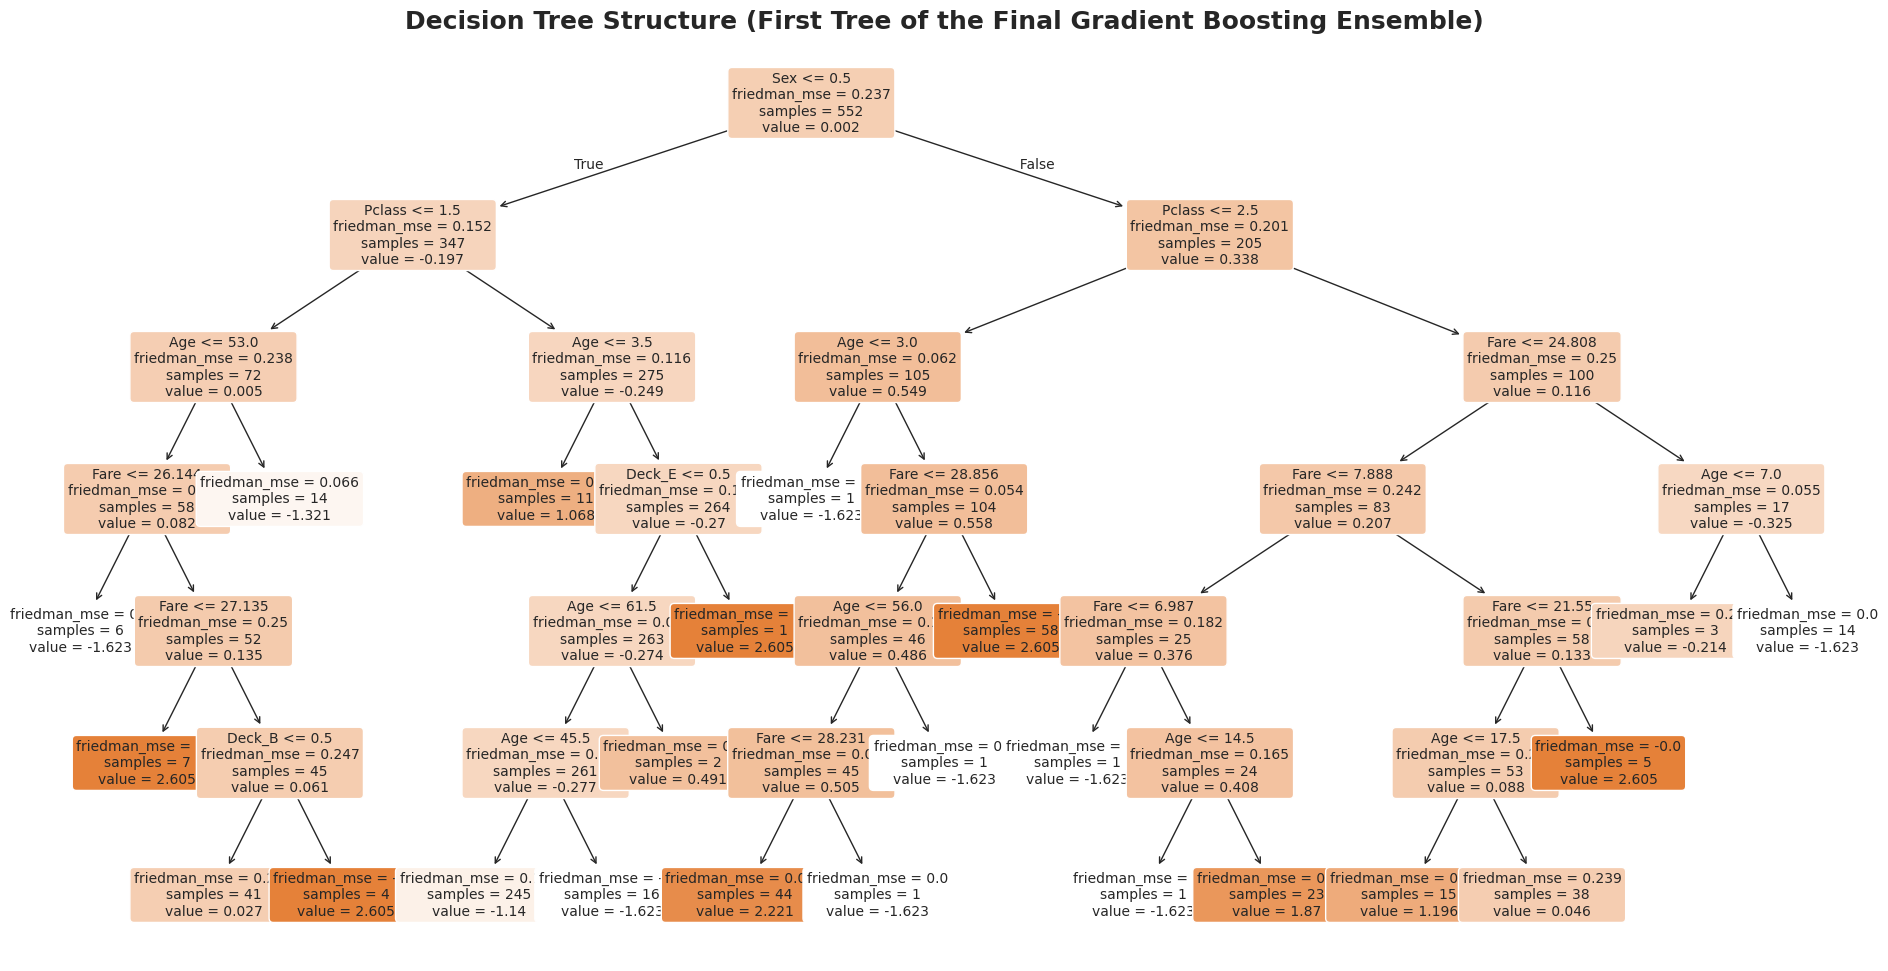

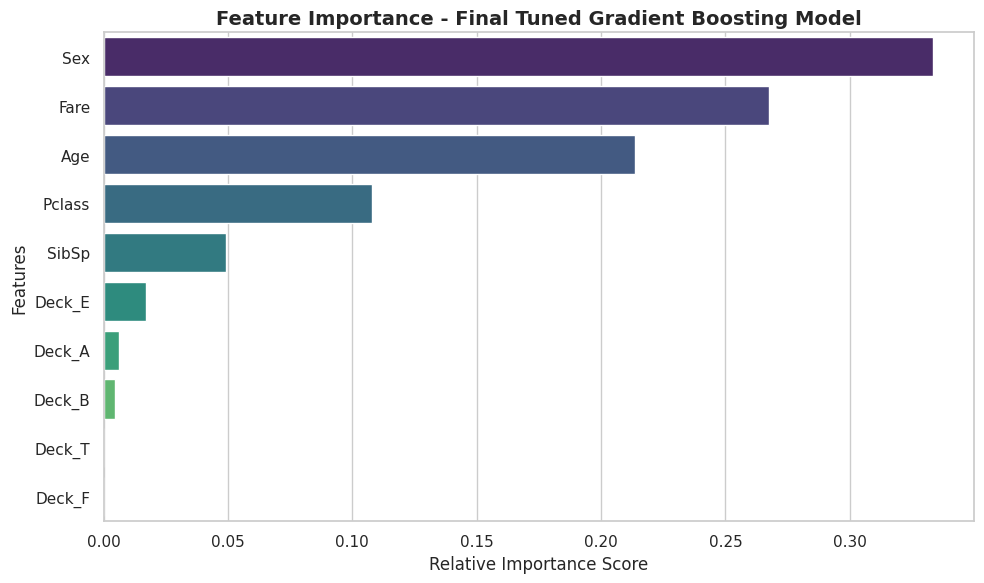

In [37]:
from sklearn.tree import plot_tree

first_tree = final_gb_clf.estimators_[0, 0]

plt.figure(figsize=(24, 12))
plot_tree(
    first_tree,
    feature_names=selected_features_gb,
    class_names=['Did Not Survive', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure (First Tree of the Final Gradient Boosting Ensemble)", fontsize=18, fontweight='bold')
plt.show()

final_importances = final_gb_clf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': selected_features_gb,
    'Importance': final_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title("Feature Importance - Final Tuned Gradient Boosting Model", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()